In [2]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.datasets import fetch_20newsgroups
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt

In [3]:
#load th 20 new datasets
newsgroups = fetch_20newsgroups(subset='all', remove = ('headers', 'footers', 'quotes'))


In [4]:
#vectorize th text data using TF_IDF
tfidf_vectorizer = TfidfVectorizer(max_df=0.5,max_features=1000, stop_words='english')
tfidf_matrix = tfidf_vectorizer.fit_transform(newsgroups.data)

In [5]:
#reduce dimensionality using LSA
lsa = TruncatedSVD(n_components=2)
lsa_matrix = lsa.fit_transform(tfidf_matrix)

In [6]:
#perform K_Mean clustring
k = 20
model = KMeans(n_clusters=k, random_state=42)
model.fit(lsa_matrix)

KMeans(n_clusters=20, random_state=42)

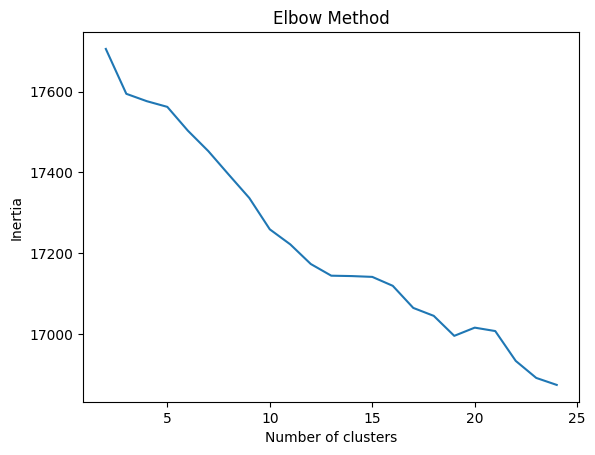

In [7]:
inertia = []
K_range = range(2, 25)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(tfidf_matrix)
    inertia.append(km.inertia_)

plt.plot(K_range, inertia)
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

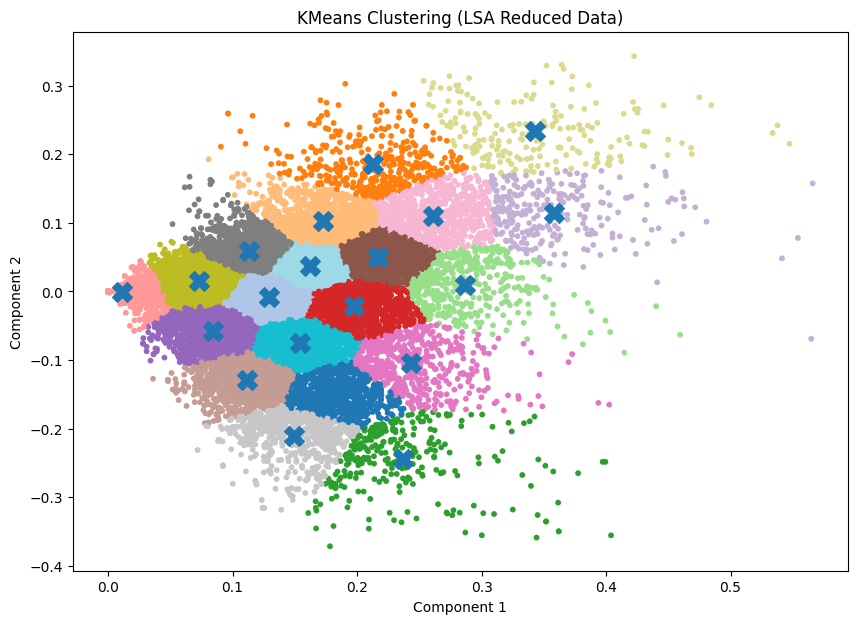

In [8]:
plt.figure(figsize=(10,7))

# scatter plot of documents
plt.scatter(lsa_matrix[:, 0], lsa_matrix[:, 1],
            c=model.labels_, cmap='tab20', s=10)

# centroids plot
centroids = model.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1],
            marker='X', s=200)

plt.title("KMeans Clustering (LSA Reduced Data)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")

plt.show()

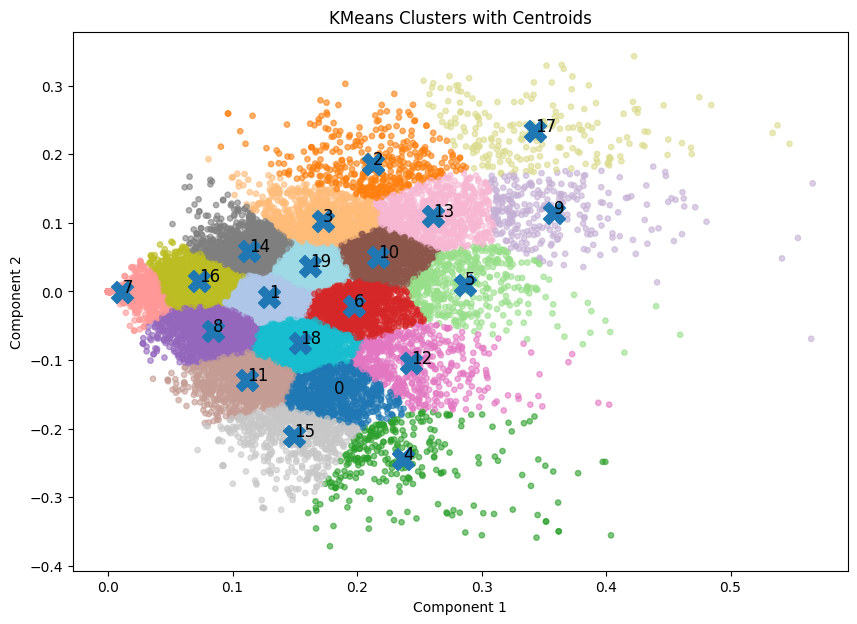

In [9]:
plt.figure(figsize=(10,7))

plt.scatter(lsa_matrix[:, 0], lsa_matrix[:, 1],
            c=model.labels_, cmap='tab20', s=15, alpha=0.6)

centroids = model.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1],
            marker='X', s=250)

for i, centroid in enumerate(centroids):
    plt.text(centroid[0], centroid[1], str(i), fontsize=12)

plt.title("KMeans Clusters with Centroids")
plt.xlabel("Component 1")
plt.ylabel("Component 2")

plt.show()